# 🧠 Autonomous Decision Intelligence Agent

An agent that **perceives** a business situation, **analyzes** options under uncertainty, **decides** within safety guardrails, **acts**, **learns** from outcomes, and **explains** every decision.

**Scenario:** a retail operator makes a daily decision: hold price, discount, raise price, or restock (small/large). Demand is seasonal and noisy, and the agent does *not* know the true model, so it must learn from experience.

## Agent loop
```
Perceive → Contextualize → Guardrails → Evaluate options → Decide → Act → Observe reward → Learn → Explain
```

| Capability | Technique used |
|---|---|
| Perception | Observation → discretized context (demand regime × stock level) |
| Decision under uncertainty | Thompson sampling (Bayesian exploration/exploitation) |
| Risk awareness | Risk-adjusted score = sampled mean − λ · std |
| Safety | Rule-based guardrails that block unsafe actions |
| Learning | Online Welford statistics per (context, action) |
| Explainability | Natural-language rationale + confidence per decision |
| Evaluation | Benchmark vs. random / fixed / rule-based baselines over multiple seeds |

Runs fully offline (numpy + pandas + matplotlib). An optional LLM narration cell is at the end.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3})

## 1. Environment (the world the agent acts in)

In [2]:
# action name -> (price multiplier, units restocked)
ACTIONS = {
    "hold":        (1.00, 0),
    "discount_10": (0.90, 0),
    "premium_10":  (1.10, 0),
    "restock_40":  (1.00, 40),
    "restock_100": (1.00, 100),
}

class RetailEnv:
    def __init__(self, seed=SEED, horizon=300):
        self.rng = np.random.default_rng(seed)
        self.t, self.horizon = 0, horizon
        self.inventory = 100
        self.base_price, self.unit_cost = 50.0, 30.0
        self._new_day()

    def _new_day(self):
        self.season = 1 + 0.4 * np.sin(2 * np.pi * self.t / 30)          # hidden truth
        self.demand_signal = self.season * self.rng.normal(1, 0.08)      # noisy view
        self.competitor_price = self.base_price * self.rng.normal(1, 0.04)

    def observe(self):
        return {"t": self.t, "inventory": int(self.inventory),
                "demand_signal": round(float(self.demand_signal), 3),
                "competitor_price": round(float(self.competitor_price), 2)}

    def step(self, action):
        mult, qty = ACTIONS[action]
        price = self.base_price * mult
        stock = self.inventory + qty
        lam = 40 * self.season * (price / self.competitor_price) ** -2.5
        demand = self.rng.poisson(max(lam, 1))
        sold = min(demand, stock)
        unmet = demand - sold
        end_inv = min(stock - sold, 400)

        profit = (sold * (price - self.unit_cost)       # margin
                  - (80 if qty > 0 else 0)              # fixed order cost
                  - 0.6 * end_inv                       # holding cost
                  - 8.0 * unmet)                        # stock-out goodwill penalty
        self.inventory = end_inv
        self.t += 1
        done = self.t >= self.horizon
        if not done:
            self._new_day()
        return float(profit), done, {"sold": int(sold), "unmet": int(unmet), "price": price}

env = RetailEnv()
print("Sample observation:", env.observe())

Sample observation: {'t': 0, 'inventory': 100, 'demand_signal': 1.024, 'competitor_price': 47.92}


## 2. The agent

In [3]:
class Stat:
    # Online mean / variance (Welford)
    def __init__(self):
        self.n, self.mean, self.m2 = 0, 0.0, 0.0
    def update(self, x):
        self.n += 1
        d = x - self.mean
        self.mean += d / self.n
        self.m2 += d * (x - self.mean)
    @property
    def std(self):
        return (self.m2 / (self.n - 1)) ** 0.5 if self.n > 1 else 0.0


class DecisionAgent:
    def __init__(self, risk_aversion=0.3, min_trials=3, seed=SEED):
        self.lam = risk_aversion
        self.min_trials = min_trials
        self.rng = np.random.default_rng(seed)
        self.stats = {}          # (context, action) -> Stat
        self.log = []            # decision records (agent memory / audit trail)

    # ---- Perceive -> Contextualize
    def context(self, obs):
        d = obs["demand_signal"]
        demand = "low" if d < 0.9 else "mid" if d < 1.15 else "high"
        s = obs["inventory"]
        stock = "low" if s < 40 else "ok" if s < 150 else "high"
        return f"demand={demand}|stock={stock}"

    # ---- Guardrails
    def guardrails(self, obs):
        blocked = {}
        if obs["inventory"] < 25:
            blocked["discount_10"] = "inventory critically low: don't discount scarce stock"
        if obs["inventory"] >= 250:
            blocked["restock_40"] = blocked["restock_100"] = "inventory already very high"
        allowed = [a for a in ACTIONS if a not in blocked]
        return allowed, blocked

    def _stat(self, ctx, a):
        return self.stats.setdefault((ctx, a), Stat())

    def _risk_adjusted_sample(self, ctx, a):
        s = self._stat(ctx, a)
        sampled_mean = self.rng.normal(s.mean, s.std / np.sqrt(max(s.n, 1)))
        return sampled_mean - self.lam * s.std

    # ---- Evaluate + Decide
    def decide(self, obs):
        ctx = self.context(obs)
        allowed, blocked = self.guardrails(obs)
        untried = [a for a in allowed if self._stat(ctx, a).n < self.min_trials]

        if untried:
            action = str(self.rng.choice(untried))
            mode, confidence = "explore", None
        else:
            draws = np.array([[self._risk_adjusted_sample(ctx, a) for a in allowed]
                              for _ in range(200)])
            wins = np.bincount(draws.argmax(axis=1), minlength=len(allowed)) / 200
            action = allowed[int(wins.argmax())]
            mode, confidence = "exploit", float(wins.max())

        s = self._stat(ctx, action)
        rec = {"t": obs["t"], "context": ctx, "action": action, "mode": mode,
               "expected_profit": round(s.mean, 1), "risk_std": round(s.std, 1),
               "confidence": confidence, "blocked": blocked, "trials": s.n}
        self.log.append(rec)
        return action, rec

    # ---- Learn
    def learn(self, ctx, action, reward):
        self._stat(ctx, action).update(reward)

    # ---- Explain
    def explain(self, rec):
        if rec["mode"] == "explore":
            why = (f"Not enough evidence for '{rec['action']}' in this situation yet "
                   f"({rec['trials']} trials), so I'm gathering data.")
        else:
            why = (f"'{rec['action']}' has the best risk-adjusted outlook here: "
                   f"avg profit ≈ {rec['expected_profit']} (±{rec['risk_std']}), "
                   f"chosen in {rec['confidence']:.0%} of simulated posterior draws.")
        guard = "".join(f" Blocked {k}: {v}." for k, v in rec["blocked"].items())
        return f"[t={rec['t']}] Context {rec['context']}. {why}{guard}"

## 3. Baselines and the simulation loop

In [4]:
def random_policy(obs, rng=np.random.default_rng(0)):
    return str(rng.choice(list(ACTIONS)))

def always_hold(obs):
    return "hold"

def rule_based(obs):
    if obs["inventory"] < 40:
        return "restock_100"
    if obs["demand_signal"] > 1.2:
        return "premium_10"
    if obs["demand_signal"] < 0.8:
        return "discount_10"
    return "hold"

def run_policy(policy, seed=SEED, horizon=300):
    env, rows, done = RetailEnv(seed, horizon), [], False
    while not done:
        obs = env.observe()
        a = policy(obs)
        r, done, info = env.step(a)
        rows.append({"t": obs["t"], "action": a, "profit": r, **info})
    return pd.DataFrame(rows)

def run_agent(seed=SEED, horizon=300, risk_aversion=0.3, agent=None):
    agent = agent or DecisionAgent(risk_aversion=risk_aversion, seed=seed)
    env, rows, done = RetailEnv(seed, horizon), [], False
    while not done:
        obs = env.observe()
        a, rec = agent.decide(obs)
        r, done, info = env.step(a)
        agent.learn(rec["context"], a, r)
        rows.append({"t": obs["t"], "action": a, "profit": r, "mode": rec["mode"], **info})
    return pd.DataFrame(rows), agent

## 4. Run the agent

In [5]:
agent_df, agent = run_agent(seed=SEED)
base = {
    "Random": run_policy(random_policy),
    "Always hold": run_policy(always_hold),
    "Rule-based": run_policy(rule_based),
}
print(f"Agent total profit: {agent_df.profit.sum():,.0f}")
for k, v in base.items():
    print(f"{k:12s} total profit: {v.profit.sum():,.0f}")

Agent total profit: 190,969
Random       total profit: 141,191
Always hold  total profit: -91,715
Rule-based   total profit: 215,198


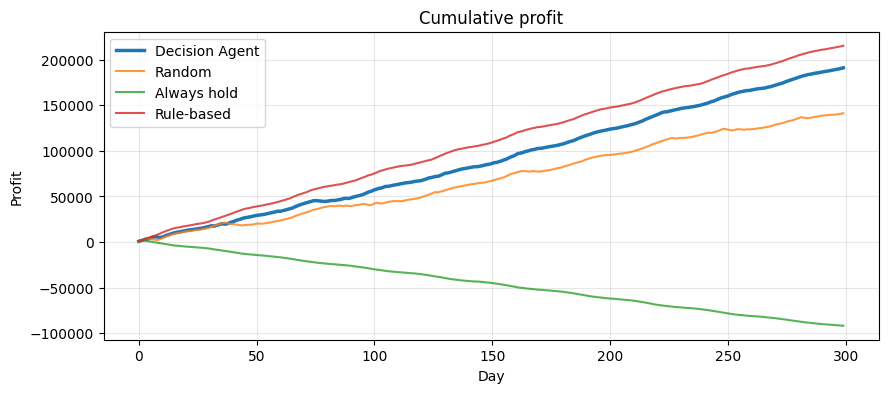

In [6]:
fig, ax = plt.subplots()
ax.plot(agent_df.profit.cumsum(), label="Decision Agent", lw=2.5)
for k, v in base.items():
    ax.plot(v.profit.cumsum(), label=k, alpha=.8)
ax.set(title="Cumulative profit", xlabel="Day", ylabel="Profit")
ax.legend()
plt.show()

## 5. Explainability: why did it decide that?

In [7]:
for rec in agent.log[-5:]:
    print(agent.explain(rec), "\n")

[t=295] Context demand=low|stock=ok. 'hold' has the best risk-adjusted outlook here: avg profit ≈ 529.0 (±120.3), chosen in 50% of simulated posterior draws. 

[t=296] Context demand=low|stock=low. 'restock_100' has the best risk-adjusted outlook here: avg profit ≈ 448.0 (±171.5), chosen in 70% of simulated posterior draws. Blocked discount_10: inventory critically low: don't discount scarce stock. 

[t=297] Context demand=low|stock=ok. 'hold' has the best risk-adjusted outlook here: avg profit ≈ 529.4 (±119.0), chosen in 51% of simulated posterior draws. 

[t=298] Context demand=low|stock=ok. 'hold' has the best risk-adjusted outlook here: avg profit ≈ 527.4 (±118.4), chosen in 46% of simulated posterior draws. 

[t=299] Context demand=mid|stock=ok. 'hold' has the best risk-adjusted outlook here: avg profit ≈ 819.8 (±150.7), chosen in 56% of simulated posterior draws. 



In [8]:
# Audit trail as a DataFrame
audit = pd.DataFrame(agent.log)
audit["explore"] = audit["mode"].eq("explore")
audit.tail(10)

,t,context,action,mode,expected_profit,risk_std,confidence,blocked,trials,explore
290,290,demand=low|stock=ok,hold,exploit,532.1,124.2,0.390,{},41,False
291,291,demand=low|stock=ok,hold,exploit,533.0,122.8,0.505,{},42,False
292,292,demand=low|stock=low,restock_100,exploit,450.6,174.1,0.660,{},28,False
293,293,demand=low|stock=ok,hold,exploit,529.9,123.0,0.455,{},43,False
294,294,demand=low|stock=ok,hold,exploit,529.0,121.7,0.470,{},44,False
295,295,demand=low|stock=ok,hold,exploit,529.0,120.3,0.495,{},45,False
296,296,demand=low|stock=low,restock_100,exploit,448.0,171.5,0.705,{'discount_10': 'inventory critically low: don...,29,False
297,297,demand=low|stock=ok,hold,exploit,529.4,119.0,0.510,{},46,False
298,298,demand=low|stock=ok,hold,exploit,527.4,118.4,0.460,{},47,False
299,299,demand=mid|stock=ok,hold,exploit,819.8,150.7,0.555,{},17,False


## 6. What did the agent learn?

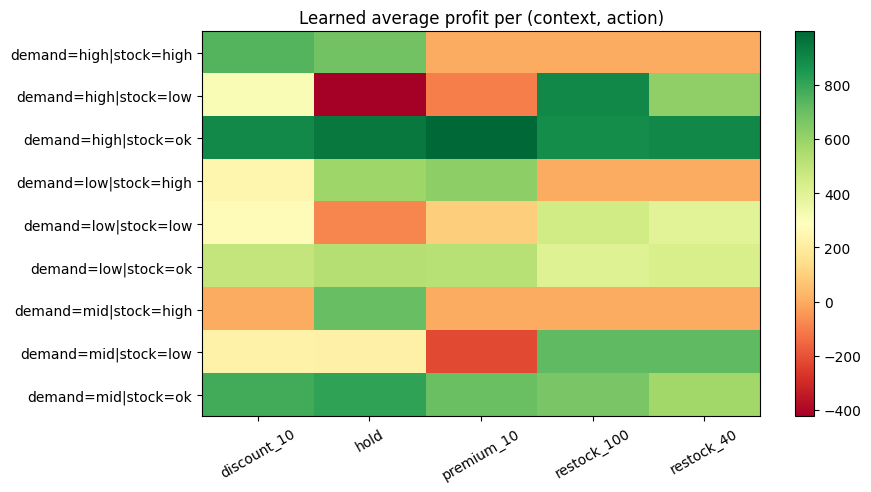

,context,action,mean_profit,n
0,demand=high|stock=high,discount_10,743.400000,1
1,demand=high|stock=low,restock_100,898.254545,44
2,demand=high|stock=ok,premium_10,997.034286,35
3,demand=low|stock=high,premium_10,624.400000,1
4,demand=low|stock=low,restock_100,447.806667,30
5,demand=low|stock=ok,hold,528.850000,48
6,demand=mid|stock=high,hold,707.400000,1
7,demand=mid|stock=low,restock_40,721.058824,17
8,demand=mid|stock=ok,hold,813.022222,18


In [9]:
q = pd.DataFrame([{"context": c, "action": a, "mean_profit": s.mean, "n": s.n}
                  for (c, a), s in agent.stats.items()])
heat = q.pivot(index="context", columns="action", values="mean_profit")

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(heat.values, aspect="auto", cmap="RdYlGn")
ax.set_xticks(range(heat.shape[1]), heat.columns, rotation=30)
ax.set_yticks(range(heat.shape[0]), heat.index)
ax.set_title("Learned average profit per (context, action)")
ax.grid(False)
plt.colorbar(im)
plt.show()

best = q.loc[q.groupby("context")["mean_profit"].idxmax()][["context", "action", "mean_profit", "n"]]
best.reset_index(drop=True)

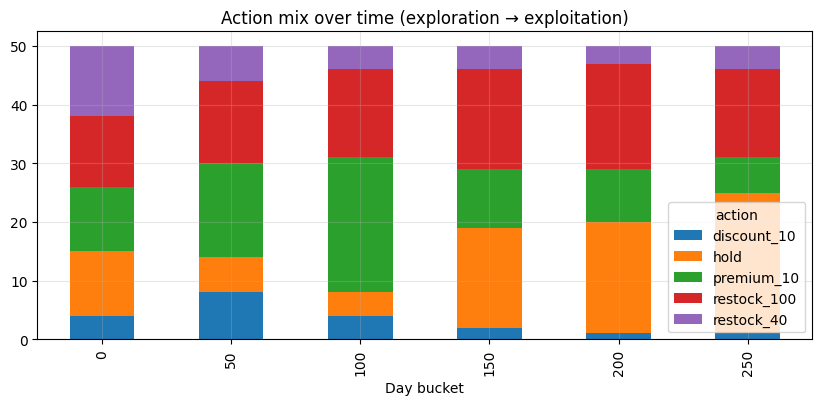

In [10]:
mix = agent_df.groupby([agent_df.t // 50 * 50, "action"]).size().unstack(fill_value=0)
mix.plot(kind="bar", stacked=True, figsize=(10, 4), title="Action mix over time (exploration → exploitation)")
plt.xlabel("Day bucket")
plt.show()

## 7. Robust benchmark across seeds

,Agent,Rule-based,Always hold,Random
mean,192465.0,218715.0,-93408.0,92695.0
std,2820.0,2368.0,783.0,115536.0
min,189587.0,213967.0,-94431.0,-72700.0
max,198378.0,221605.0,-91633.0,196673.0


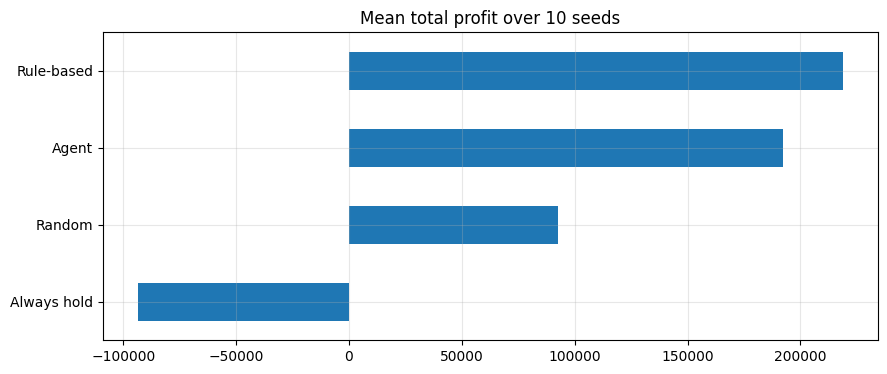

In [11]:
seeds = range(10)
res = []
for s in seeds:
    ag, _ = run_agent(seed=s)
    res.append({"seed": s, "Agent": ag.profit.sum(),
                "Rule-based": run_policy(rule_based, seed=s).profit.sum(),
                "Always hold": run_policy(always_hold, seed=s).profit.sum(),
                "Random": run_policy(lambda o: random_policy(o, np.random.default_rng(s)), seed=s).profit.sum()})
res = pd.DataFrame(res).set_index("seed")
display(res.describe().loc[["mean", "std", "min", "max"]].round(0))
res.mean().sort_values().plot(kind="barh", title="Mean total profit over 10 seeds")
plt.show()

## 8. Risk appetite: tune λ (risk aversion)

In [12]:
rows = []
for lam in [0.0, 0.3, 1.0, 2.0]:
    totals = [run_agent(seed=s, risk_aversion=lam)[0].profit.sum() for s in range(8)]
    daily_std = np.mean([run_agent(seed=s, risk_aversion=lam)[0].profit.std() for s in range(8)])
    rows.append({"risk_aversion": lam, "mean_total_profit": np.mean(totals), "avg_daily_volatility": daily_std})
pd.DataFrame(rows).round(1)

,risk_aversion,mean_total_profit,avg_daily_volatility
0,0.0,192347.5,342.1
1,0.3,192626.4,340.6
2,1.0,189947.1,341.4
3,2.0,185417.6,330.2


## 9. (Optional) LLM narration layer
Turns the audit trail into an executive summary. Set `ANTHROPIC_API_KEY` and `pip install anthropic` to enable it. The agent's decisions never depend on it.

In [13]:
def narrate_with_llm(agent, n=8):
    key = os.getenv("ANTHROPIC_API_KEY")
    if not key:
        return "Set ANTHROPIC_API_KEY to enable LLM narration."
    import anthropic
    client = anthropic.Anthropic(api_key=key)
    facts = "\n".join(agent.explain(r) for r in agent.log[-n:])
    msg = client.messages.create(
        model="claude-sonnet-4-6", max_tokens=500,
        messages=[{"role": "user", "content":
                   "You are a decision-intelligence analyst. Summarize these agent decisions "
                   "for an executive in 5 bullets, flagging risks:\n" + facts}])
    return msg.content[0].text

print(narrate_with_llm(agent))

Set ANTHROPIC_API_KEY to enable LLM narration.


## 10. Next steps
- Replace `RetailEnv` with real data (CSV/DB/API) behind the same `observe()` / `step()` interface.
- Swap the bandit for a full RL method (Q-learning, PPO) to capture multi-day effects like inventory carry-over.
- Add forecasting (Prophet / ARIMA) to enrich the observation.
- Add human-in-the-loop approval for low-confidence or high-impact actions.
- Log decisions to a database for governance and audit.